# 0. The first step here is to create the toy dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

We know that
$$\dfrac{dh}{dt}=\alpha\,u(t)-\beta\sqrt{h(t)},$$ with $\alpha=k_p/A$, $\beta=c/A$.

Euler forward:
$$h_{k+1}=h_k+\Delta t[\alpha u_k-\beta\sqrt{h_k}],\qquad y_k=h_k+e_k.$$

In [2]:
#Parameters
alpha=0.6
beta=0.6
h0=1

dt=0.3
N=1500

#random u generation
u=np.zeros(N)
palier_length=20
nb_paliers=int(N/palier_length)
random_generator=np.random.default_rng(0)
u_levels=random_generator.uniform(0.7, 2.3, nb_paliers)
for i in range(len(u_levels)):
    level=u_levels[i]
    u[i*palier_length:i*palier_length+palier_length]=level
t=np.arange(1500)*dt

#water level generation
h=np.zeros(N)
h[0]=h0
for k in range(N-1):
    h[k+1]=h[k]+dt*(alpha*u[k]-beta*np.sqrt(h[k]))

Text(0.5, 0, 'k')

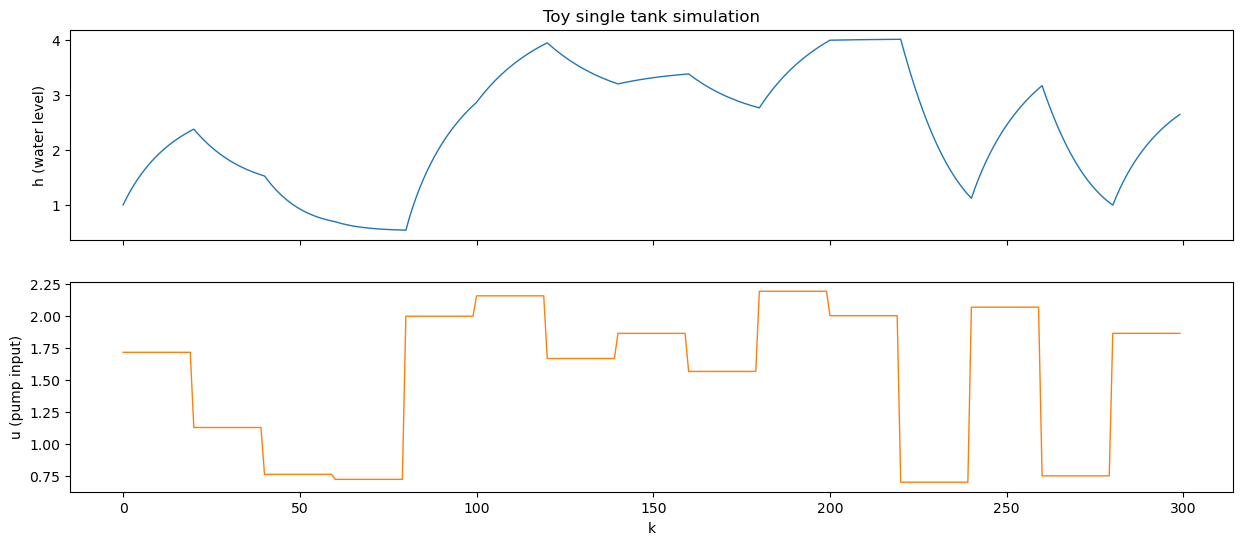

In [3]:
fig, ax=plt.subplots(2, 1, figsize=(15,6), sharex=True)
ax[0].plot(h[:300], lw=1) 
ax[0].set_ylabel("h (water level)")
ax[0].set_title("Toy single tank simulation")

ax[1].plot(u[:300], lw=1, color="C1") 
ax[1].set_ylabel("u (pump input)")
ax[1].set_xlabel("k")

### that was a simulation -> we need to create 2 datasets (train & val)

In [4]:
N_tr=1500
N_val=1000

#random u generations
u_tr=np.zeros(N_tr)
u_val=np.zeros(N_val)

palier_length=20
nb_paliers_tr=int(N_tr/palier_length)
nb_paliers_val=int(N_val/palier_length)

random_generator_tr=np.random.default_rng(0)
random_generator_val=np.random.default_rng(10)

u_levels_tr=random_generator_tr.uniform(0.7, 2.3, nb_paliers_tr)
for i in range(len(u_levels_tr)):
    level_tr=u_levels_tr[i]
    u_tr[i*palier_length:i*palier_length+palier_length]=level_tr

u_levels_val=random_generator_val.uniform(0.7, 2.3, nb_paliers_val)
for i in range(len(u_levels_val)):
    level_val=u_levels_val[i]
    u_val[i*palier_length:i*palier_length+palier_length]=level_val

#water level generation
h_tr=np.zeros(N_tr)
h_val=np.zeros(N_val)

h_tr[0]=h0
h_val[0]=h0

for k in range(N_tr-1):
    h_tr[k+1]=h_tr[k]+dt*(alpha*u_tr[k]-beta*np.sqrt(h_tr[k]))
    
#add the noise: y is noisy water level while h is the true one 
y_tr=h_tr+random_generator_tr.normal(0,0.05,N_tr)

for k in range(N_val-1):
    h_val[k+1]=h_val[k]+dt*(alpha*u_val[k]-beta*np.sqrt(h_val[k]))
#add the noise: y is noisy water level while h is the true one 
y_val=h_val+random_generator_val.normal(0,0.05,N_val)

Text(0.5, 0, 'k')

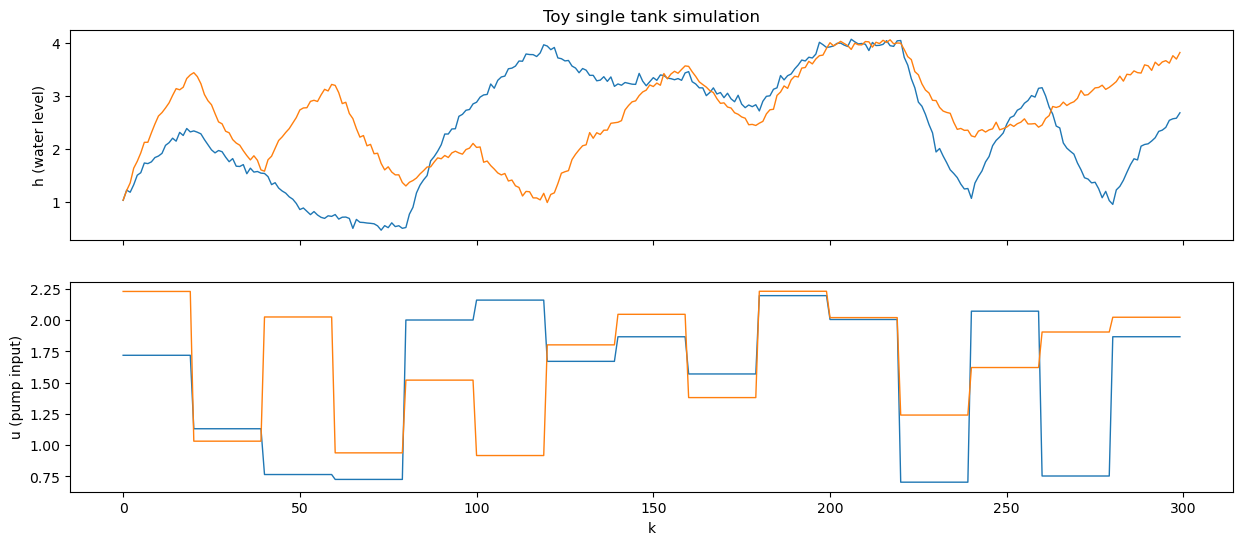

In [5]:
fig, ax=plt.subplots(2, 1, figsize=(15,6), sharex=True)
ax[0].plot(y_tr[:300], color="C0", lw=1) 
ax[0].plot(y_val[:300], color="C1", lw=1) 
ax[0].set_ylabel("h (water level)")
ax[0].set_title("Toy single tank simulation")

ax[1].plot(u_tr[:300], lw=1, color="C0") 
ax[1].plot(u_val[:300], lw=1, color="C1") 
ax[1].set_ylabel("u (pump input)")
ax[1].set_xlabel("k")

### Toy is now created, with train and test sets. 

### Now we need to create the regressor vector

In [6]:
#Lags generator function
def build_lags(y, u, n_y, n_u, n_k):
    N=len(y) 
    k0=max(n_y, n_k+n_u-1)
    Y, U, t=[], [], []
    for k in range(k0, N):
        Y.append([y[k-1-j] for j in range(n_y)])     #y(k-1) .. y(k-n_y)
        U.append([u[k-n_k-j] for j in range(n_u)])    #u(k-n_k) .. u(k-n_k-n_u+1)
        t.append(y[k])
    return np.array(Y), np.array(U), np.array(t), k0

#Base functions generator 
def feature_map(Y, U, basis, n_k):
    n_y, n_u=Y.shape[1], U.shape[1]
    cols, names=[], []
    
    cols.append(Y)                        
    names += [f"h(k-{j+1})" for j in range(n_y)]
    
    cols.append(U)                          
    names += [f"u(k-{n_k+j})" for j in range(n_u)]
    
    cols.append(np.sqrt(np.maximum(Y, 0)));  
    names += [f"sqrt(h(k-{j+1}))" for j in range(n_y)]
    
    if basis == "B":
        cols.append(Y**2)
        names += [f"h(k-{j+1})^2" for j in range(n_y)]
        
        cols.append(U**2);                   
        names += [f"u(k-{n_k+j})^2" for j in range(n_u)]
        
        if n_y == n_u:
            cols.append(Y*U)
            names += [f"h(k-{j+1})*u(k-{n_k+j})" for j in range(n_y)]
    return np.hstack(cols), names    

In [7]:
n_k = 1
Y1, U1, t1, _ = build_lags(y_tr, u_tr, 1, 1, n_k)
PhiA1, namesA1 = feature_map(Y1, U1, "A", n_k)
ols1 = LinearRegression().fit(PhiA1, t1)

print("features :", namesA1)
print("coefs estimes :", ols1.coef_, " | intercept:", round(ols1.intercept_, 3))
print("coefs vrais : [1.0, dt*alpha, -dt*beta] =", [1.0, round(dt*alpha, 3), round(-dt*beta, 3)])

features : ['h(k-1)', 'u(k-1)', 'sqrt(h(k-1))']
coefs estimes : [ 1.00528194  0.18868236 -0.21154276]  | intercept: 0.022
coefs vrais : [1.0, dt*alpha, -dt*beta] = [1.0, 0.18, -0.18]


### SUPER INTERESTING FOR THE REPORT!!!!:

The theoretical model ($h_{k+1}=h_k+\Delta t[\alpha u_k-\beta\sqrt{h_k}]$) is linear in the 3 features ($h(k-1), u(k-1) and \sqrt(h(k-1))$). The theoretical coefficients are [1, dt*alpha, -dt*beta] and we see that the OLS find these coefficients!

That means that we are on a good basis and that we can investigate further

# 1. Now that the toy dataset is created, we need to define metrcis we will use

$$R^2(y,\hat y)=1-\dfrac{\sum_n (y_n-\hat y_n)^2}{\sum_n (y_n-\bar y)^2},\quad
\text{MSE}=\dfrac{1}{N'}\sum_n(y_n-\hat y_n)^2,\quad
\text{RMSE}=\sqrt{\text{MSE}}.$$

- RMSE has the same unit as y so directly comparable to noise

- MSE is sensible to large deviations

- $R^2$ has no unit, if 1 it is perfect, if 0 it is as bad as the mean

In [8]:
#function to show the metrics to not redo the same thing over and over
def show_metrics(y_true, y_pred, label):
    r2=r2_score(y_true, y_pred)
    mse= mean_squared_error(y_true, y_pred)
    rmse=root_mean_squared_error(y_true, y_pred)
    print(f"{label} :::::  R2 = {r2:.4f}   MSE = {mse:.5f}   RMSE = {rmse:.5f}")
    return dict(R2=r2, MSE=mse, RMSE=rmse)

# 2. OLS on basis A and B

We reconstruct 2 design matrices with $n_y=n_u=5$, $n_k=1$ :

- basis A (physics-informed minimal): $1$, lags, $\sqrt{y_{\text{lag}}}$
- basis B (poly + physics): A + $y^2$, $u^2$, and interactions $y\cdot u$

We then standardise $\Phi$'s collumns with a StandardScaler adjusted on the train and then the same transfo is applied on the validation set

In [9]:
ny=5
nu=5
nk=1

#build regressor
Ytr, Ulagtr, ttr, k0tr=build_lags(y_tr, u_tr, ny, nu, nk)
Yval, Ulagval, tval, k0val=build_lags(y_val, u_val, ny, nu, nk)
print(f"size train = {len(ttr)}, and size val = {len(tval)}")

#build features
PhiAtr, namesA=feature_map(Ytr, Ulagtr, "A", nk)
PhiBtr, namesB=feature_map(Ytr, Ulagtr, "B", nk)
PhiAval, _=feature_map(Yval, Ulagval, "A", nk)
PhiBval, _=feature_map(Yval, Ulagval, "B", nk)

print(f"basis A: {PhiAtr.shape[1]} features")
"""
print("features:")
for i, name in enumerate(namesA):
    print(f"{i+1}. {name}")
"""    
print(f"basis B: {PhiBtr.shape[1]} features")
"""
print("features:")
for i, name in enumerate(namesB):
    print(f"{i+1}. {name}")
"""

size train = 1495, and size val = 995
basis A: 15 features
basis B: 30 features


'\nprint("features:")\nfor i, name in enumerate(namesB):\n    print(f"{i+1}. {name}")\n'

In [10]:
#standardisation
scA=StandardScaler().fit(PhiAtr)
scB=StandardScaler().fit(PhiBtr)
ZAtr=scA.transform(PhiAtr)
ZAval=scA.transform(PhiAval)
ZBtr=scB.transform(PhiBtr)
ZBval=scB.transform(PhiBval)

olsA=LinearRegression().fit(ZAtr, ttr)
olsB=LinearRegression().fit(ZBtr, ttr)

mA=show_metrics(tval, olsA.predict(ZAval), "OLS basis A")
mB=show_metrics(tval, olsB.predict(ZBval), "OLS basis B")

OLS basis A :::::  R2 = 0.9957   MSE = 0.00279   RMSE = 0.05283
OLS basis B :::::  R2 = 0.9958   MSE = 0.00279   RMSE = 0.05281


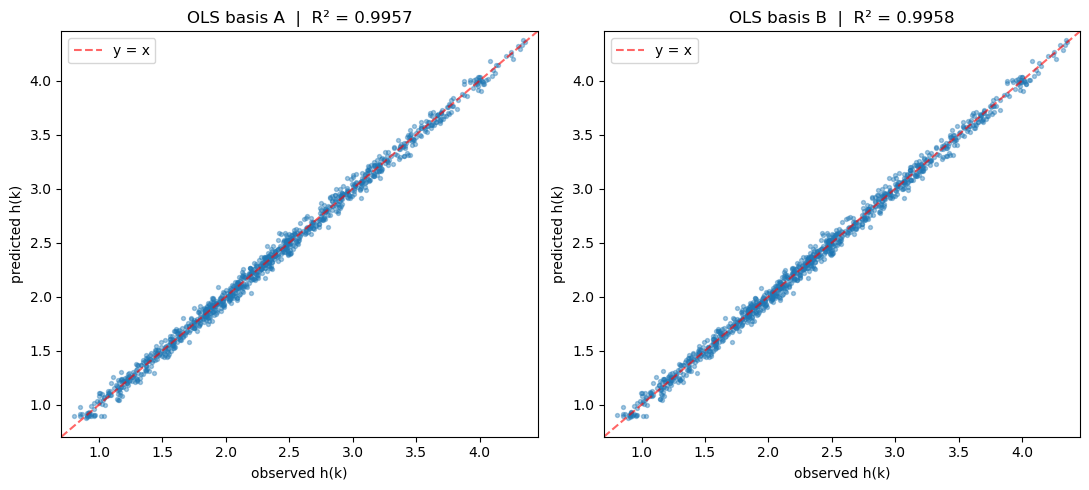

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, m, Zval, title in [(axes[0], olsA, ZAval, "OLS basis A"),
                              (axes[1], olsB, ZBval, "OLS basis B")]:
    yp = m.predict(Zval)
    ax.scatter(tval, yp, s=8, alpha=0.4)
    lo, hi = tval.min() - 0.1, tval.max() + 0.1
    ax.plot([lo, hi], [lo, hi], "r--", alpha=0.6, label="y = x")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("observed h(k)"); ax.set_ylabel("predicted h(k)")
    ax.set_title(f"{title}  |  R² = {r2_score(tval, yp):.4f}")
    ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### Observation

We clearly see that on this toy basis B (30 params) doesnt bring anything to the model and could overfit. We need regularisation. 

# 3. k-fold cross-validation: choose $\alpha$

# 3.1. Ridge regression (L2)

We minimise
$$\mathcal{L}_{\text{Ridge}}(w) = \tfrac1{2N'}\lVert t - \Phi w\rVert_2^2 + \alpha\,\lVert w\rVert_2^2.$$
Closed form sol:
$$\hat w_{\text{Ridge}} = (\Phi^\top\Phi + \alpha I)^{-1}\Phi^\top t.$$
$\alpha I$ lowers all the coef till 0 but not to 0. 

In [12]:
ridgeB=RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5).fit(ZBtr, ttr)
print(f"optimal alpha (Ridge): {ridgeB.alpha_:.5f}")
print("\n1-step prediction for validation:")
mBols=show_metrics(tval, olsB.predict(ZBval), "OLS basis B")
mBrid=show_metrics(tval, ridgeB.predict(ZBval), "Ridge basis B")

optimal alpha (Ridge): 0.26827

1-step prediction for validation:
OLS basis B :::::  R2 = 0.9958   MSE = 0.00279   RMSE = 0.05281
Ridge basis B :::::  R2 = 0.9958   MSE = 0.00279   RMSE = 0.05281


## 3.2. Lasso regression (L1)

We minimise
$$\mathcal{L}_{\text{Lasso}}(w) = \tfrac1{2N'}\lVert t - \Phi w\rVert_2^2 + \alpha\,\lVert w\rVert_1.$$
There is no closed form sol but it is a convex problem. 

In [13]:
lassoB=LassoCV(alphas=np.logspace(-4, 1, 60), cv=5, max_iter=20000, random_state=0).fit(ZBtr, ttr)
print(f"optimal alpha (Lasso): {lassoB.alpha_:.5f}")
nz=int(np.sum(np.abs(lassoB.coef_) > 1e-6))
print(f"features retained: {nz}/30")
print("\n1-step prediction for validation:")
mBlasso=show_metrics(tval, lassoB.predict(ZBval), "Lasso basis B")

optimal alpha (Lasso): 0.00018
features retained: 14/30

1-step prediction for validation:
Lasso basis B :::::  R2 = 0.9957   MSE = 0.00280   RMSE = 0.05290


### Now the thing is that we could think lasso and ridge have the same perf... Lets add noise to see its effects

In [14]:
rng_demo=np.random.default_rng(7)
nsub=80
idx=rng_demo.choice(len(ttr), nsub, replace=False)
Zsub=ZBtr[idx]
tsub=ttr[idx]

nnoise=50
rng_n=np.random.default_rng(42)
noise_tr=rng_n.standard_normal((nsub, nnoise))
noiseval=rng_n.standard_normal((ZBval.shape[0], nnoise))
aug_tr=np.hstack([Zsub, noise_tr])
aug_val=np.hstack([ZBval, noiseval])

print(f"train: {nsub} points, {aug_tr.shape[1]} features {ZBtr.shape[1]} reals + {nnoise} noise")

ols_aug=LinearRegression().fit(aug_tr, tsub)
lasso_aug=LassoCV(alphas=np.logspace(-4, 1, 60), cv=5, max_iter=80000, random_state=0).fit(aug_tr, tsub)

show_metrics(tval, ols_aug.predict(aug_val), "OLS + 50 features noise")
show_metrics(tval, lasso_aug.predict(aug_val), "Lasso + 50 features noise")
nz_real=int(np.sum(np.abs(lasso_aug.coef_[:ZBtr.shape[1]]) > 1e-6))
nz_noise=int(np.sum(np.abs(lasso_aug.coef_[ZBtr.shape[1]:]) > 1e-6))

print(f"Lasso retained {nz_real}/30 real features and {nz_noise}/50 noise features")

train: 80 points, 80 features 30 reals + 50 noise
OLS + 50 features noise :::::  R2 = -105.5339   MSE = 69.95755   RMSE = 8.36406
Lasso + 50 features noise :::::  R2 = 0.9946   MSE = 0.00355   RMSE = 0.05960
Lasso retained 11/30 real features and 3/50 noise features


## 3.3 visual comparison of the coefs

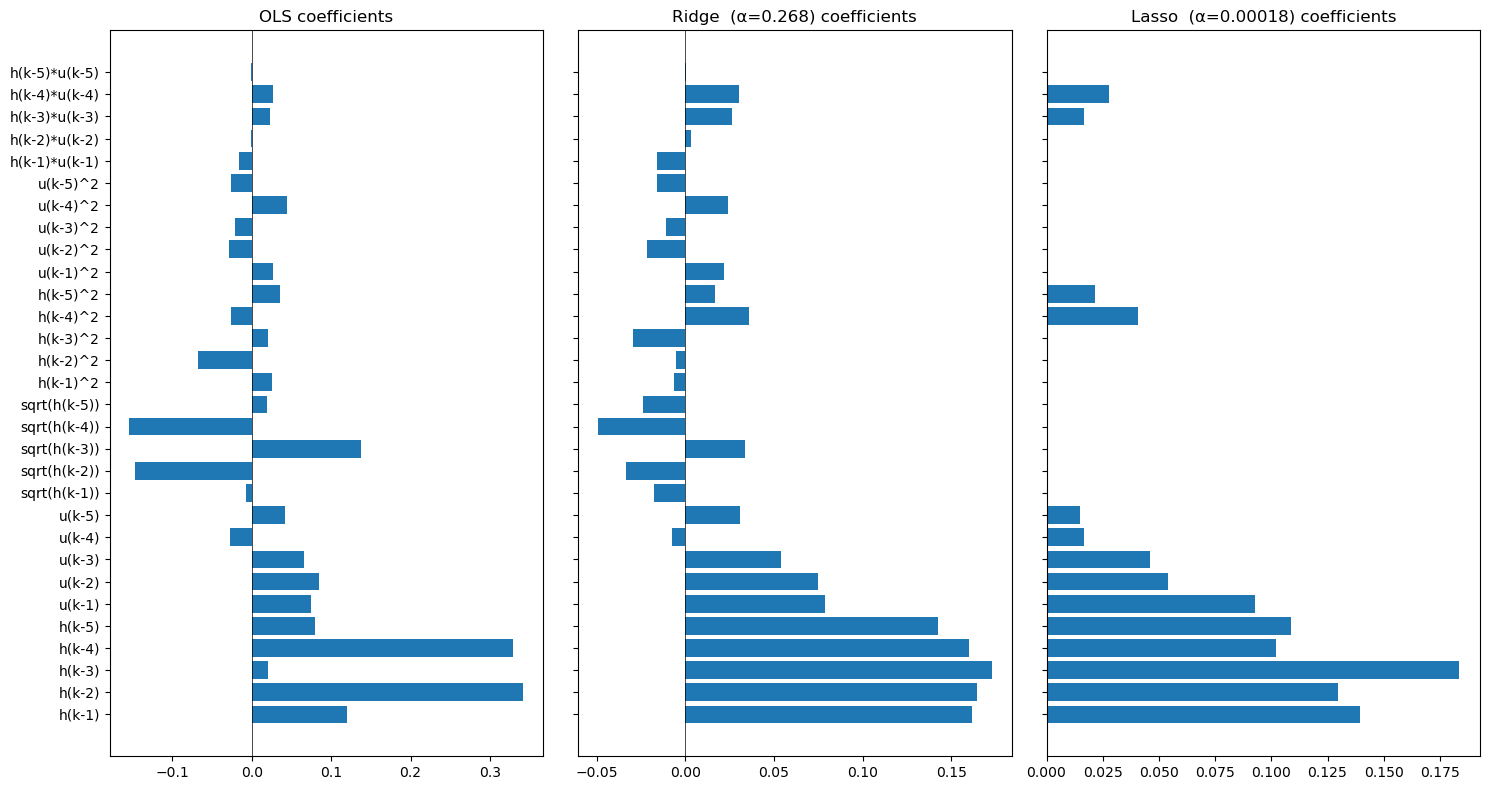

In [15]:
fig, axes=plt.subplots(1, 3, figsize=(15, 8), sharey=True)
for ax, m, title in [(axes[0], olsB,   "OLS"),
                      (axes[1], ridgeB, f"Ridge  (α={ridgeB.alpha_:.3f})"),
                      (axes[2], lassoB, f"Lasso  (α={lassoB.alpha_:.5f})")]:
    ax.barh(namesB, m.coef_)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{title} coefficients")
plt.tight_layout(); plt.show()

### Observation:

Lasso clearly do his job but doesnt select the $\sqrt{h_{\text{lags}}}$ even if it is the real dynamics of the model?? That's because we are at small values, and then $\sqrt{h}$ is well approximed by a limited Taylor developmt

# 4. 1-step prediction vs free simultion

till here we made 1-step pred: to predict y(k), we give **actual** past values $y(k-1)$,... Its easy because the model is "reset" at each step with the actual measures.

In free sim, we give the model only the first points and the we reinject its own predictions. Errors accumulate and it may drift.

$$\hat y(k) = w^\top\varphi\big(\underbrace{\hat y(k-1),\dots,\hat y(k-n_y)}_{\text{past predictions}},\ u(k-n_k),\dots\big).$$

In [16]:
#free simulation: only the first k0 points are given
def simulate_free(model, scaler, basis,ytrue, u, ny, nu, nk):
    N = len(ytrue)
    k0 = max(ny, nk + nu - 1)
    ysim = ytrue.astype(float).copy()
    for k in range(k0, N):
        Yk = np.array([[ysim[k-1-j] for j in range(ny)]])
        Uk = np.array([[u[k-n_k-j]   for j in range(nu)]])
        Phi, _ = feature_map(Yk, Uk, basis, nk)
        ysim[k] = model.predict(scaler.transform(Phi))[0]
    return ysim, k0

sim_ols, k0s=simulate_free(olsB, scB, "B", y_val, u_val, ny, nu, nk)
sim_ridge, _=simulate_free(ridgeB, scB, "B", y_val, u_val, ny, nu, nk)
sim_lasso, _=simulate_free(lassoB, scB, "B", y_val, u_val, ny, nu, nk)

sim_ols_m=show_metrics(y_val[k0s:], sim_ols[k0s:], "OLS basis B (free sim)")
sim_ridge_m=show_metrics(y_val[k0s:], sim_ridge[k0s:], "Ridge basis B (free sim)")
sim_lasso_m=show_metrics(y_val[k0s:], sim_lasso[k0s:], "Lasso basis B (free sim)")

OLS basis B (free sim) :::::  R2 = 0.9962   MSE = 0.00252   RMSE = 0.05019
Ridge basis B (free sim) :::::  R2 = 0.9961   MSE = 0.00255   RMSE = 0.05046
Lasso basis B (free sim) :::::  R2 = 0.9959   MSE = 0.00267   RMSE = 0.05171


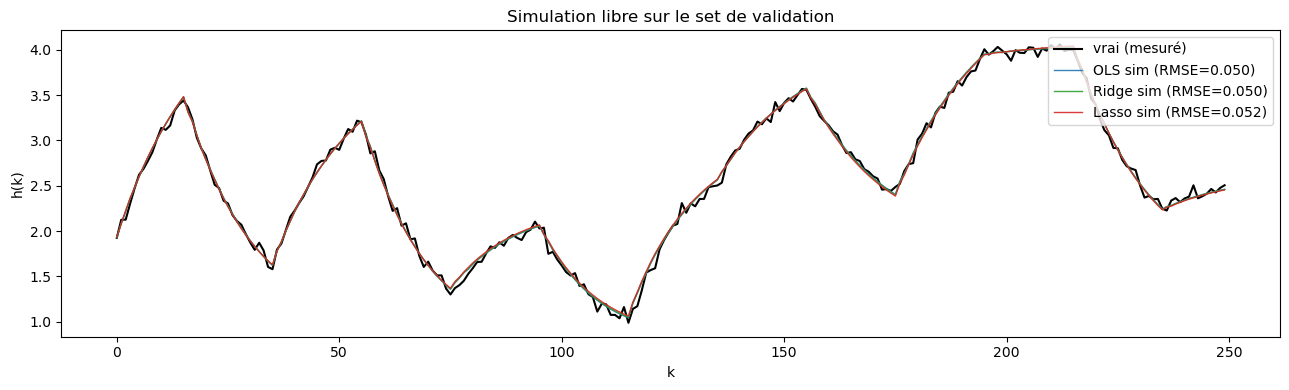

In [17]:
w = slice(k0s, k0s + 250)
plt.figure(figsize=(13, 4))
plt.plot(y_val[w], "k", lw=1.5, label="vrai (mesuré)")
plt.plot(sim_ols[w],   "C0", lw=1, alpha=0.9, label=f"OLS sim (RMSE={sim_ols_m['RMSE']:.3f})")
plt.plot(sim_ridge[w], "C2", lw=1, alpha=0.9, label=f"Ridge sim (RMSE={sim_ridge_m['RMSE']:.3f})")
plt.plot(sim_lasso[w], "C3", lw=1, alpha=0.9, label=f"Lasso sim (RMSE={sim_lasso_m['RMSE']:.3f})")
plt.xlabel("k"); plt.ylabel("h(k)"); plt.title("Simulation libre sur le set de validation")
plt.legend(loc="upper right"); plt.tight_layout(); plt.show()

### Observations

On toy, all models are really good in free simulation.